In [2]:
"""
Complete corrected script for dinosaur colour prediction.
- Converts all measurements to nanometres (nm).
- Combines training data from both provided CSV files.
- Trains Random Forest and SVM.
- Validates on theropod fossils.
- Predicts colour for non‑theropod dinosaurs.
"""

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------
# 1. Load and prepare training data
# ------------------------------------------------------------

# ---- Training set 1: modern_training.csv (already in nm) ----
train1 = pd.read_csv("modern_training.csv")
# Keep only necessary columns and standardise colour names
train1 = train1[["Colour", "length_nm", "width_nm", "aspect_ratio"]].copy()
train1["Colour"] = train1["Colour"].str.lower()
train1.rename(columns={"Colour": "colour"}, inplace=True)

# ---- Training set 2: modern_bird_training.csv (RAW values are in µm!) ----
train2_raw = pd.read_csv("modern_bird_training.csv")
# Multiply length and width by 1000 to convert µm → nm
train2_raw["length_nm"] = train2_raw["length_nm"] * 1000
train2_raw["width_nm"]  = train2_raw["width_nm"] * 1000
train2_raw["aspect_ratio"] = train2_raw["length_nm"] / train2_raw["width_nm"]
train2 = train2_raw[["colour", "length_nm", "width_nm", "aspect_ratio"]].copy()
train2["colour"] = train2["colour"].str.lower()

# ---- Combine both training sets ----
train = pd.concat([train1, train2], ignore_index=True)
print(f"Total training samples after unit correction: {len(train)}")
print("Class distribution:")
print(train["colour"].value_counts())

# ------------------------------------------------------------
# 2. Load validation and test sets (both already in nm)
# ------------------------------------------------------------
val = pd.read_csv("theropod_validation.csv")
val["known_colour"] = val["known_colour"].str.lower()

test = pd.read_csv("non_theropod_test.csv")

# ------------------------------------------------------------
# Feature engineering (ADD THIS)
# ------------------------------------------------------------
def engineer_dino_features(df):
    df = df.copy()

    df['volume_proxy'] = (
        (4/3) * np.pi *
        (df['length_nm'] / 2) *
        ((df['width_nm'] / 2) ** 2)
    )

    df['log_length'] = np.log1p(df['length_nm'])
    df['log_width']  = np.log1p(df['width_nm'])

    return df

train = engineer_dino_features(train)
val   = engineer_dino_features(val)
test  = engineer_dino_features(test)

# ------------------------------------------------------------
# 3. Encode colour labels
# ------------------------------------------------------------
le = LabelEncoder()
train["colour_enc"] = le.fit_transform(train["colour"])
val["colour_enc"]   = le.transform(val["known_colour"])

# Feature columns
features = ["aspect_ratio", "volume_proxy", "log_length", "log_width"]
X_train = train[features]
y_train = train["colour_enc"]
X_val   = val[features]
y_val   = val["colour_enc"]
X_test  = test[features]

# ------------------------------------------------------------
# 4. Standardise features (important for SVM, also helps RF)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------------------
# 5. Random Forest
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    class_weight='balanced_subsample',
    random_state=42
)
rf.fit(X_train_scaled, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print("\n" + "="*50)
print("RANDOM FOREST")
print(f"5‑fold CV accuracy: {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")

val_pred_rf = rf.predict(X_val_scaled)
print(f"Theropod validation accuracy: {accuracy_score(y_val, val_pred_rf):.3f}")
print("\nClassification report (theropod validation):")
print(classification_report(y_val, val_pred_rf, target_names=le.classes_, zero_division=0))

# Predict non‑theropods
test_pred_rf = rf.predict(X_test_scaled)
test_proba_rf = rf.predict_proba(X_test_scaled)
print("\nPredictions for non‑theropods (RF):")
for i, row in test.iterrows():
    pred_colour = le.inverse_transform([test_pred_rf[i]])[0]
    prob = max(test_proba_rf[i])
    print(f"  {row['species']}: {pred_colour} (prob={prob:.2f})")

# Feature importances
print("\nRF feature importances:")
for f, imp in zip(features, rf.feature_importances_):
    print(f"  {f}: {imp:.3f}")

# ------------------------------------------------------------
# 6. Support Vector Machine
# ------------------------------------------------------------
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print("\n" + "="*50)
print("SUPPORT VECTOR MACHINE")
print(f"5‑fold CV accuracy: {svm_cv_scores.mean():.3f} (+/- {svm_cv_scores.std():.3f})")

val_pred_svm = svm.predict(X_val_scaled)
print(f"Theropod validation accuracy: {accuracy_score(y_val, val_pred_svm):.3f}")

test_pred_svm = svm.predict(X_test_scaled)
test_proba_svm = svm.predict_proba(X_test_scaled)
print("\nPredictions for non‑theropods (SVM):")
for i, row in test.iterrows():
    pred_colour = le.inverse_transform([test_pred_svm[i]])[0]
    prob = max(test_proba_svm[i])
    print(f"  {row['species']}: {pred_colour} (prob={prob:.2f})")

# ------------------------------------------------------------
# End of script
# ------------------------------------------------------------

Total training samples after unit correction: 555
Class distribution:
colour
iridescent    179
grey          170
brown         140
black          48
penguin        18
Name: count, dtype: int64

RANDOM FOREST
5‑fold CV accuracy: 0.623 (+/- 0.025)
Theropod validation accuracy: 0.250

Classification report (theropod validation):
              precision    recall  f1-score   support

       black       0.50      0.40      0.44         5
       brown       0.00      0.00      0.00         1
        grey       0.00      0.00      0.00         1
  iridescent       0.00      0.00      0.00         1
     penguin       0.00      0.00      0.00         0

    accuracy                           0.25         8
   macro avg       0.10      0.08      0.09         8
weighted avg       0.31      0.25      0.28         8


Predictions for non‑theropods (RF):
  Psittacosaurus lujiatunensis: brown (prob=0.95)
  Psittacosaurus lujiatunensis: brown (prob=0.76)
  Diplodocus sp. 10660: brown (prob=0.50)
  Di

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load and prepare data (same as before, but remove penguin)
train1 = pd.read_csv("modern_training.csv")
train1 = train1[["Colour", "length_nm", "width_nm", "aspect_ratio"]].copy()
train1["Colour"] = train1["Colour"].str.lower()
train1.rename(columns={"Colour": "colour"}, inplace=True)

train2_raw = pd.read_csv("modern_bird_training.csv")
train2_raw["length_nm"] = train2_raw["length_nm"] * 1000
train2_raw["width_nm"] = train2_raw["width_nm"] * 1000
train2_raw["aspect_ratio"] = train2_raw["length_nm"] / train2_raw["width_nm"]
train2 = train2_raw[["colour", "length_nm", "width_nm", "aspect_ratio"]].copy()
train2["colour"] = train2["colour"].str.lower()

train = pd.concat([train1, train2], ignore_index=True)
# Remove penguin – not relevant to dinosaurs
train = train[train['colour'] != 'penguin']

# Simple features: aspect_ratio only (most robust to taphonomy)
features = ['aspect_ratio']
X_train = train[features]
y_train = train['colour']

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train_enc)

# Load validation (theropod)
val = pd.read_csv("theropod_validation.csv")
val["known_colour"] = val["known_colour"].str.lower()
X_val = val[features]
y_val = val["known_colour"]
y_val_enc = le.transform(y_val)
X_val_scaled = scaler.transform(X_val)

# Load test (non-theropod)
test = pd.read_csv("non_theropod_test.csv")
X_test = test[features]
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    'QDA': QuadraticDiscriminantAnalysis(),
    'SVM': SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42),
    'RF': RandomForestClassifier(n_estimators=150, max_depth=5, class_weight='balanced_subsample', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*40}\n{name}")
    # Handle QDA separately (no probability)
    if name == 'QDA':
        model.fit(X_train_bal, y_train_bal)
        cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
        print(f"5‑fold CV: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
        val_pred = model.predict(X_val_scaled)
        print(f"Theropod validation accuracy: {accuracy_score(y_val_enc, val_pred):.3f}")
        # After val_pred = model.predict(X_val_scaled) for each model
        print("\nIndividual theropod predictions:")
        for i, (idx, row) in enumerate(val.iterrows()):
            true_color = row['known_colour']
            pred_color = le.inverse_transform([val_pred[i]])[0]
            correct = "✓" if true_color == pred_color else "✗"
            print(f"  {row['species']:25s} | true: {true_color:10s} | pred: {pred_color:10s} | {correct}")
        # Non-theropod predictions
        test_pred = model.predict(X_test_scaled)
        print("Non‑theropod predictions:")
        for i, row in test.iterrows():
            print(f"  {row['species']}: {le.inverse_transform([test_pred[i]])[0]}")
    else:
        model.fit(X_train_bal, y_train_bal)
        cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='accuracy')
        print(f"5‑fold CV: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
        val_pred = model.predict(X_val_scaled)
        print(f"Theropod validation accuracy: {accuracy_score(y_val_enc, val_pred):.3f}")
        print("\nIndividual theropod predictions:")
        for i, (idx, row) in enumerate(val.iterrows()):
            true_color = row['known_colour']
            pred_color = le.inverse_transform([val_pred[i]])[0]
            correct = "✓" if true_color == pred_color else "✗"
            print(f"  {row['species']:25s} | true: {true_color:10s} | pred: {pred_color:10s} | {correct}")
        test_pred = model.predict(X_test_scaled)
        test_proba = model.predict_proba(X_test_scaled)
        print("Non‑theropod predictions:")
        for i, row in test.iterrows():
            pred = le.inverse_transform([test_pred[i]])[0]
            prob = max(test_proba[i])
            print(f"  {row['species']}: {pred} (conf={prob:.2f})")


QDA
5‑fold CV: 0.622 (+/- 0.013)
Theropod validation accuracy: 0.750

Individual theropod predictions:
  Anchiornis huxleyi        | true: black      | pred: black      | ✓
  Archaeopteryx lithographica | true: black      | pred: black      | ✓
  Caudipteryx zoui          | true: black      | pred: black      | ✓
  Microraptor sp.           | true: iridescent | pred: grey       | ✗
  Sinosauropteryx           | true: brown      | pred: brown      | ✓
  Wulong sp. (ulna)         | true: black      | pred: black      | ✓
  Wulong sp. (ilium)        | true: black      | pred: black      | ✓
  Wulong sp. (abdomen)      | true: grey       | pred: brown      | ✗
Non‑theropod predictions:
  Psittacosaurus lujiatunensis: brown
  Psittacosaurus lujiatunensis: brown
  Diplodocus sp. 10660: brown
  Diplodocus 10662: brown

SVM
5‑fold CV: 0.637 (+/- 0.008)
Theropod validation accuracy: 0.750

Individual theropod predictions:
  Anchiornis huxleyi        | true: black      | pred: black      | ✓
  

C:\Users\HP\AppData\Local\Temp\ipykernel_672\3528426973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='colour', y='aspect_ratio', order=order,


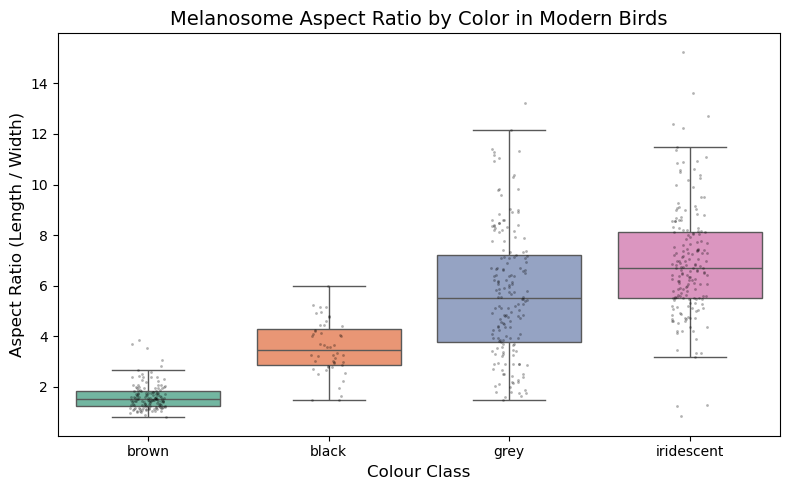

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use only the four main colour classes (exclude 'penguin' if present)
plot_data = train[train['colour'].isin(['black', 'brown', 'grey', 'iridescent'])].copy()

# Order boxes by median aspect ratio (optional)
order = plot_data.groupby('colour')['aspect_ratio'].median().sort_values().index

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_data, x='colour', y='aspect_ratio', order=order,
            palette='Set2', showfliers=False)

# Add swarm plot to show individual points (helps see density)
sns.stripplot(data=plot_data, x='colour', y='aspect_ratio', order=order,
              color='black', alpha=0.3, size=2)

plt.ylabel('Aspect Ratio (Length / Width)', fontsize=12)
plt.xlabel('Colour Class', fontsize=12)
plt.title('Melanosome Aspect Ratio by Color in Modern Birds', fontsize=14)

# Save high-resolution figure
plt.tight_layout()
plt.savefig('figure1_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Index(['species', 'length_nm', 'width_nm', 'aspect_ratio', 'log_length',
       'log_width', 'genus'],
      dtype='object')
['Psittacosaurus lujiatunensis' 'Diplodocus sp. 10660' 'Diplodocus 10662']
['Psittacosaurus' 'Diplodocus']


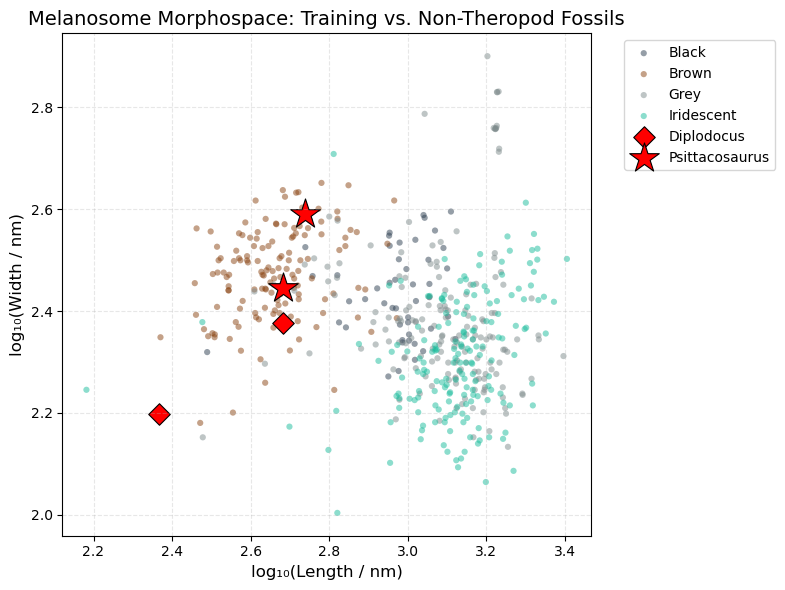

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Prepare training data
# ----------------------------

train_plot = train[
    train['colour'].isin(['black', 'brown', 'grey', 'iridescent'])
].copy()

train_plot['log_length'] = np.log10(train_plot['length_nm'])
train_plot['log_width'] = np.log10(train_plot['width_nm'])


# ----------------------------
# Prepare fossil data
# ----------------------------

test_plot = test.copy()

test_plot['log_length'] = np.log10(test_plot['length_nm'])
test_plot['log_width'] = np.log10(test_plot['width_nm'])

test_plot['genus'] = test_plot['species'].str.split().str[0]


# Check the data
print(test_plot.columns)
print(test_plot['species'].unique())
print(test_plot['genus'].unique())

# Define colours for each class
colour_palette = {
    'black': '#2c3e50',
    'brown': '#8B4513',
    'grey': '#7f8c8d',
    'iridescent': '#1abc9c'
}

fig, ax = plt.subplots(figsize=(8, 6))

# Plot training data
for colour, group in train_plot.groupby('colour'):
    ax.scatter(
        group['log_length'],
        group['log_width'],
        label=colour.capitalize(),
        color=colour_palette[colour],
        alpha=0.5,
        s=20,
        edgecolor='none'
    )

# ----------------------------
# Plot fossil specimens
# ----------------------------
# Marker for each fossil genus
marker_map = {
    'Psittacosaurus': '*',
    'Diplodocus': 'D'
}

size_map = {
    'Psittacosaurus': 500,
    'Diplodocus': 120
}

# Plot fossils grouped by genus
for genus, group in test_plot.groupby('genus'):
    ax.scatter(
        group['log_length'],
        group['log_width'],
        marker=marker_map[genus],
        s=size_map[genus],
        color='red',
        edgecolor='black',
        linewidth=0.8,
        label=genus
    )


ax.set_xlabel('log₁₀(Length / nm)', fontsize=12)
ax.set_ylabel('log₁₀(Width / nm)', fontsize=12)
ax.set_title('Melanosome Morphospace: Training vs. Non-Theropod Fossils', fontsize=14)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_distribution_shift.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
from lazypredict.Supervised import LazyClassifier

# These must be defined earlier in your notebook
X_train_lazy = X_train_bal   # shape (716, n_features)
y_train_lazy = y_train_bal   # shape (716,)
X_val_lazy   = X_val_scaled  # shape (8, n_features)
y_val_lazy   = y_val_enc     # shape (8,)

print("Shapes before LazyClassifier:")
print("X_train_bal :", X_train_bal.shape)
print("y_train_bal :", y_train_bal.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("y_val_enc   :", y_val_enc.shape)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(
    X_train=X_train_lazy,
    y_train=y_train_lazy,
    X_test=X_val_lazy,
    y_test=y_val_lazy
)

print(models.sort_values('Accuracy', ascending=False).head(10))

Shapes before LazyClassifier:
X_train_bal : (716, 1)
y_train_bal : (716,)
X_val_scaled: (8, 1)
y_val_enc   : (8,)
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
LabelPropagation                  0.875               0.75  0.857143   
LabelSpreading                    0.875               0.75  0.857143   
LinearSVC                         0.750               0.70       NaN   
CalibratedClassifierCV            0.750               0.70  0.815476   
SVC                               0.750               0.50       NaN   
QuadraticDiscriminantAnalysis     0.750               0.50  0.857143   
PassiveAggressiveClassifier       0.750               0.50       NaN   
AdaBoostClassifier                0.750               0.50  0.678571   
GaussianNB                        0.750               0.50  0.857143   
SGDClassifier                     0.625               0.25       NaN   

                     

In [15]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import AdaBoostClassifier

# Re-train the top supervised models (default params, as used by LazyPredict)
models_to_test = {
    'LinearSVC': LinearSVC(random_state=42, dual=True),  # dual=True for n_samples > n_features
    'CalibratedClassifierCV': CalibratedClassifierCV(SVC(random_state=42), cv=3),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42),  # matches the 62.5% model
}

print("\n--- Predictions on Non-Theropods ---")
for name, model in models_to_test.items():
    model.fit(X_train_bal, y_train_bal)
    
    # Predict on non-theropods
    preds = model.predict(X_test_scaled)
    
    # Get probabilities if available
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)
        confs = [max(p) for p in probs]
    else:
        confs = ["N/A"] * len(X_test_scaled)
    
    print(f"\n{name}:")
    for i, row in test.iterrows():
        pred_label = le.inverse_transform([preds[i]])[0]
        print(f"  {row['species']}: {pred_label} (conf={confs[i]})")


--- Predictions on Non-Theropods ---

LinearSVC:
  Psittacosaurus lujiatunensis: brown (conf=N/A)
  Psittacosaurus lujiatunensis: brown (conf=N/A)
  Diplodocus sp. 10660: brown (conf=N/A)
  Diplodocus 10662: brown (conf=N/A)

CalibratedClassifierCV:
  Psittacosaurus lujiatunensis: brown (conf=0.7164611573418481)
  Psittacosaurus lujiatunensis: brown (conf=0.736681657002245)
  Diplodocus sp. 10660: brown (conf=0.7324251381890071)
  Diplodocus 10662: brown (conf=0.7165856960085503)


D:\python\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



AdaBoost:
  Psittacosaurus lujiatunensis: brown (conf=0.32557197125299114)
  Psittacosaurus lujiatunensis: brown (conf=0.32557197125299114)
  Diplodocus sp. 10660: brown (conf=0.32557197125299114)
  Diplodocus 10662: brown (conf=0.32557197125299114)

SGDClassifier:
  Psittacosaurus lujiatunensis: black (conf=N/A)
  Psittacosaurus lujiatunensis: brown (conf=N/A)
  Diplodocus sp. 10660: brown (conf=N/A)
  Diplodocus 10662: black (conf=N/A)
